# World Models — Imagination, JEPA & Latent Dynamics
### `05_World_Models/Dreamer_JEPA_World_Models/`

> **Learning goal:** Build a minimal **learned simulator** of an environment: encode observations into a latent state, predict the next latent under actions (**intervention**), optionally decode, and use imagination for control. Compare **pixel reconstruction** world models (Dreamer-family) with **joint-embedding predictive** ideas (JEPA): predict in representation space, not pixels.

> **Prerequisites:** Phase 4 SSMs (latent dynamics), Phase 1–3 do-calculus, Phase 6 MCTS/MPC intuition.

> **Primary references:** Ha & Schmidhuber World Models (2018); Hafner et al. PlaNet / Dreamer / DreamerV3; Schrittwieser MuZero; LeCun JEPA path paper; V-JEPA (Bardes et al.).

---

## Map of this notebook

| § | Topic | What you implement |
|---|--------|--------------------|
| 1 | Why world models | Agent loop with imagination |
| 2 | Toy env: GridWorld | Ground-truth transitions |
| 3 | RSSM-style latent model | Encoder + deterministic dynamics + decoder (NumPy/Torch) |
| 4 | Train by next-obs prediction | Loss curves, rollout quality |
| 5 | Imagination MPC | Plan actions inside the model |
| 6 | JEPA-style latent prediction | Predict embeddings, not pixels |
| 7 | Failure modes | Model bias, compounding error |
| 8 | Bridge to MuZero / V-JEPA / agents | Concept map |

---

## 1. Why world models?

A **policy** maps $o \mapsto a$. A **world model** maps $(o_{\le t}, a_{\le t}) \mapsto$ predictions of future $o$, $r$, or latents $z$.

$$
\begin{aligned}
z_t &= \mathrm{enc}_\theta(o_t, z_{t-1}, a_{t-1}) \\
z_{t+1} &= \mathrm{dyn}_\theta(z_t, a_t) \qquad \text{(this is }\mathrm{do}(a_t)\text{ in latent space)} \\
\hat o_{t+1}, \hat r_t &= \mathrm{dec}_\theta(z_{t+1})
\end{aligned}
$$

| Approach | Train objective | Act-time compute |
|----------|-----------------|------------------|
| Model-free RL | $Q$ or $\pi$ from interaction | 1 forward pass |
| **World model + MPC/MCTS** | next-latent / reward / value | search in imagination |
| Imitation / BC | match expert $a$ | 1 forward (no counterfactuals) |

**Causal reminder:** training data is often observational. If actions were confounded, a naively learned $P(o'|o,a)$ can be wrong under $\mathrm{do}(a)$. In simulators and online RL logs with known actions, we *are* closer to interventional data — still watch for covariate shift.

---

## 2. Toy environment — discrete GridWorld

We use a tiny grid so every latent and prediction is inspectable. Same spirit as the MCTS notebook, but now we **learn** the transition function from data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

np.set_printoptions(precision=3, suppress=True)
torch.manual_seed(0)
rng = np.random.default_rng(0)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
device = torch.device("cpu")

# Grid layout (rows, cols). S start, G goal, T trap, # wall, . empty
LAYOUT = [
    list("S..T."),
    list(".#.#."),
    list("....G"),
]
H, W = len(LAYOUT), len(LAYOUT[0])
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # U D L R
ANAMES = ["U", "D", "L", "R"]

def find_cell(ch):
    for r in range(H):
        for c in range(W):
            if LAYOUT[r][c] == ch:
                return (r, c)
    raise ValueError(ch)

START, GOAL, TRAP = find_cell("S"), find_cell("G"), find_cell("T")

def obs_vector(pos):
    """One-hot position in R^{H*W} — our pixels."""
    v = np.zeros(H * W, dtype=np.float32)
    v[pos[0] * W + pos[1]] = 1.0
    return v

def step_true(pos, a):
    if pos in (GOAL, TRAP):
        return pos, 0.0, True
    dr, dc = ACTIONS[a]
    nxt = (pos[0] + dr, pos[1] + dc)
    r, c = nxt
    if not (0 <= r < H and 0 <= c < W) or LAYOUT[r][c] == "#":
        nxt = pos
        reward = -0.05
    elif nxt == TRAP:
        reward = -1.0
    elif nxt == GOAL:
        reward = 1.0
    else:
        reward = -0.01
    done = nxt in (GOAL, TRAP)
    return nxt, reward, done

def random_policy_rollout(max_steps=30):
    pos = START
    traj = []
    for _ in range(max_steps):
        a = int(rng.integers(0, 4))
        nxt, r, done = step_true(pos, a)
        traj.append((obs_vector(pos), a, r, obs_vector(nxt), done))
        pos = nxt
        if done:
            break
    return traj

# Collect offline dataset of transitions
dataset = []
for _ in range(800):
    dataset.extend(random_policy_rollout())
print(f"Transitions collected: {len(dataset)}")
print(f"Obs dim: {H*W}, example reward stats: "
      f"mean={np.mean([t[2] for t in dataset]):.3f}")

Transitions collected: 18321
Obs dim: 15, example reward stats: mean=-0.041


## 3. RSSM-style model (educational mini-Dreamer)

Dreamer uses a **Recurrent State-Space Model** with stochastic latents. We implement a simpler cousin that still has the right shape:

| Module | Symbol | Role |
|--------|--------|------|
| Encoder | $z_t = e_\theta(o_t)$ | Compress observation |
| Dynamics | $z_{t+1} = f_\theta(z_t, a_t)$ | Latent transition under action |
| Decoders | $\hat o_{t+1}, \hat r_t = d_\theta(z_{t+1})$ | Reconstruct obs + reward |

Training loss (one-step):

$$
\mathcal{L}
=
\| \hat o_{t+1} - o_{t+1} \|^2
+ \beta \| \hat r_t - r_t \|^2
+ \lambda \| z_{t+1} - e_\theta(o_{t+1}) \|^2
$$

The last term is a **latent consistency** regularizer (predict encoder features of the true next obs) — a baby step toward JEPA.

Final loss total=0.0016  obs=0.0000  r=0.0000  z=0.0149


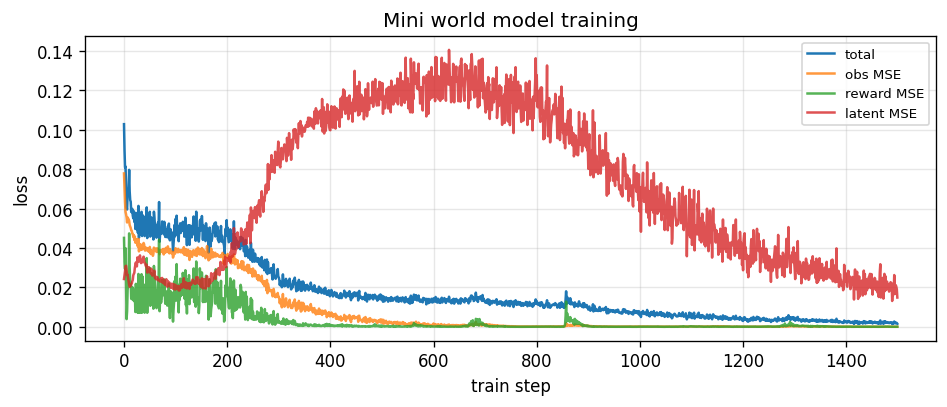

In [2]:
class MiniWorldModel(nn.Module):
    def __init__(self, obs_dim, n_actions=4, z_dim=32, hidden=64):
        super().__init__()
        self.z_dim = z_dim
        self.n_actions = n_actions
        self.enc = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, z_dim),
        )
        self.dyn = nn.Sequential(
            nn.Linear(z_dim + n_actions, hidden), nn.Tanh(),
            nn.Linear(hidden, z_dim),
        )
        self.dec_o = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, obs_dim),
        )
        self.dec_r = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def encode(self, o):
        return self.enc(o)

    def imagine_step(self, z, a_idx):
        a = F.one_hot(a_idx, self.n_actions).float()
        z_next = self.dyn(torch.cat([z, a], dim=-1))
        o_hat = self.dec_o(z_next)
        r_hat = self.dec_r(z_next).squeeze(-1)
        return z_next, o_hat, r_hat

obs_dim = H * W
model = MiniWorldModel(obs_dim).to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)

def batchify(data, batch_size=128):
    idx = rng.choice(len(data), size=batch_size, replace=False)
    o = torch.tensor(np.stack([data[i][0] for i in idx]), device=device)
    a = torch.tensor([data[i][1] for i in idx], dtype=torch.long, device=device)
    r = torch.tensor([data[i][2] for i in idx], dtype=torch.float32, device=device)
    op = torch.tensor(np.stack([data[i][3] for i in idx]), device=device)
    return o, a, r, op

losses = []
for step in range(1500):
    o, a, r, op = batchify(dataset)
    z = model.encode(o)
    z_next, o_hat, r_hat = model.imagine_step(z, a)
    z_tgt = model.encode(op).detach()  # stop-grad target like BYOL/JEPA
    loss_o = F.mse_loss(o_hat, op)
    loss_r = F.mse_loss(r_hat, r)
    loss_z = F.mse_loss(z_next, z_tgt)
    loss = loss_o + 0.5 * loss_r + 0.1 * loss_z
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append((loss.item(), loss_o.item(), loss_r.item(), loss_z.item()))

L = np.array(losses)
print(f"Final loss total={L[-1,0]:.4f}  obs={L[-1,1]:.4f}  r={L[-1,2]:.4f}  z={L[-1,3]:.4f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(L[:, 0], label="total", lw=1.5)
ax.plot(L[:, 1], label="obs MSE", alpha=0.8)
ax.plot(L[:, 2], label="reward MSE", alpha=0.8)
ax.plot(L[:, 3], label="latent MSE", alpha=0.8)
ax.set_xlabel("train step"); ax.set_ylabel("loss")
ax.set_title("Mini world model training")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("WM_A_train_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Open-loop imagination quality

Encode start, then roll the **dynamics only** for $H$ steps with a fixed action sequence (no feeding real observations). This is what MPC/MCTS does inside the model — compounding error appears here.

True positions:      [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4)]
Imagined positions:  [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4)]
True rewards:        [-0.01 -0.01 -0.01 -0.01 -0.01  1.  ]
Imagined rewards:    [-0.017 -0.017 -0.057  0.038 -0.057  0.787]


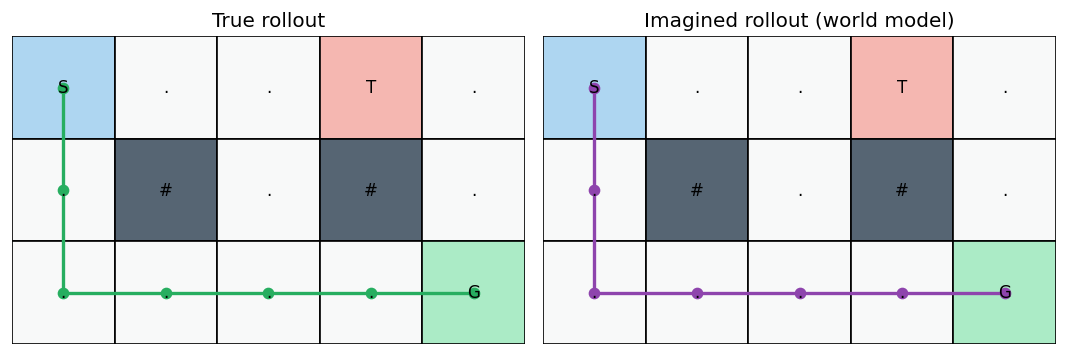

In [3]:
@torch.no_grad()
def imagine_trajectory(model, pos0, actions):
    o = torch.tensor(obs_vector(pos0), device=device).unsqueeze(0)
    z = model.encode(o)
    pred_pos = [pos0]
    true_pos = [pos0]
    pred_r, true_r = [], []
    pos = pos0
    for a in actions:
        z, o_hat, r_hat = model.imagine_step(z, torch.tensor([a], device=device))
        # decode predicted position = argmax one-hot
        p = int(o_hat.argmax().item())
        pred_pos.append((p // W, p % W))
        pred_r.append(float(r_hat.item()))
        pos, r, done = step_true(pos, a)
        true_pos.append(pos)
        true_r.append(r)
        if done:
            # continue imagining even if true episode ended
            pass
    return pred_pos, true_pos, pred_r, true_r

# Action sequence that should approach the goal if model is good
seq = [1, 1, 3, 3, 3, 3]  # D,D,R,R,R,R
pred_pos, true_pos, pred_r, true_r = imagine_trajectory(model, START, seq)
print("True positions:     ", true_pos)
print("Imagined positions: ", pred_pos)
print("True rewards:       ", np.round(true_r, 3))
print("Imagined rewards:   ", np.round(pred_r, 3))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, path, title, color in [
    (axes[0], true_pos, "True rollout", "#27AE60"),
    (axes[1], pred_pos, "Imagined rollout (world model)", "#8E44AD"),
]:
    for r in range(H):
        for c in range(W):
            ch = LAYOUT[r][c]
            face = {"S": "#AED6F1", "G": "#ABEBC6", "T": "#F5B7B1",
                    "#": "#566573", ".": "#F8F9F9"}[ch]
            ax.add_patch(plt.Rectangle((c, H - 1 - r), 1, 1, facecolor=face,
                                       edgecolor="k"))
            ax.text(c + 0.5, H - 1 - r + 0.5, ch, ha="center", va="center")
    xs = [c + 0.5 for (_, c) in path]
    ys = [H - 1 - r + 0.5 for (r, _) in path]
    ax.plot(xs, ys, "o-", color=color, lw=2)
    ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title)
plt.tight_layout()
plt.savefig("WM_B_imagination_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Imagination MPC — plan without the true env

**Model Predictive Control (simple):** for candidate action sequences, sum discounted imagined rewards; pick the best first action; replan each step (receding horizon).

This is the continuous cousin of MCTS: both use the model as an interventional simulator.

MPC path: [(0, 0), (0, 1), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 1), (0, 2), (0, 1), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2)]
Return: -0.7600000000000002 rewards: [-0.01 -0.01 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.01 -0.01 -0.01 -0.01
 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05 -0.05]


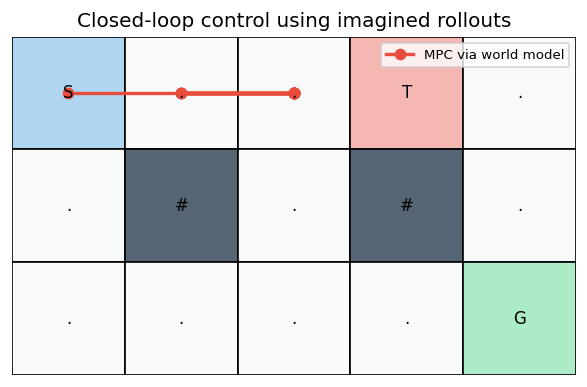

In [4]:
@torch.no_grad()
def mpc_action(model, pos, horizon=4, n_samples=80, gamma=0.97):
    best_ret, best_seq = -1e9, None
    o0 = torch.tensor(obs_vector(pos), device=device).unsqueeze(0)
    z0 = model.encode(o0)
    for _ in range(n_samples):
        actions = [int(rng.integers(0, 4)) for _ in range(horizon)]
        z = z0.clone()
        G, disc = 0.0, 1.0
        for a in actions:
            z, _, r_hat = model.imagine_step(z, torch.tensor([a], device=device))
            G += disc * float(r_hat.item())
            disc *= gamma
        if G > best_ret:
            best_ret, best_seq = G, actions
    return best_seq[0], best_seq, best_ret

def run_mpc_episode(max_steps=20):
    pos = START
    path = [pos]
    rewards = []
    for t in range(max_steps):
        a, seq, val = mpc_action(model, pos)
        nxt, r, done = step_true(pos, a)
        path.append(nxt)
        rewards.append(r)
        pos = nxt
        if done:
            break
    return path, rewards

path_mpc, rews = run_mpc_episode()
print("MPC path:", path_mpc)
print("Return:", sum(rews), "rewards:", np.round(rews, 3))

fig, ax = plt.subplots(figsize=(5, 3.5))
for r in range(H):
    for c in range(W):
        ch = LAYOUT[r][c]
        face = {"S": "#AED6F1", "G": "#ABEBC6", "T": "#F5B7B1",
                "#": "#566573", ".": "#F8F9F9"}[ch]
        ax.add_patch(plt.Rectangle((c, H - 1 - r), 1, 1, facecolor=face, edgecolor="k"))
        ax.text(c + 0.5, H - 1 - r + 0.5, ch, ha="center", va="center")
xs = [c + 0.5 for (_, c) in path_mpc]
ys = [H - 1 - r + 0.5 for (r, _) in path_mpc]
ax.plot(xs, ys, "o-", color="#E74C3C", lw=2, label="MPC via world model")
ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Closed-loop control using imagined rollouts")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("WM_C_mpc_path.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. JEPA-style prediction — skip the pixels

**Joint-Embedding Predictive Architecture (idea):**

- Context encoder $f_\theta$ maps past / visible region → representation $s$
- Target encoder $f_{\bar\theta}$ (often EMA copy) maps future / masked region → $s^+$
- Predictor $g_\phi$ maps $s$ (+ mask/action tokens) → $\hat s^+$
- Loss: distance in embedding space only — **no pixel decoder**

$$
\mathcal{L}_{\mathrm{JEPA}} = \big\| g_\phi(f_\theta(x_{\mathrm{ctx}})) - \mathrm{sg}(f_{\bar\theta}(x_{\mathrm{tgt}})) \big\|^2
$$

**Why this matters:** reconstructing every pixel wastes capacity on textures irrelevant to control. Predicting **abstract state** aligns with planning and causal reasoning.

Below: same grid, but we train only latent prediction $z_{t+1} \approx e(o_{t+1})$ with an EMA target encoder — no obs decoder in the loss.

JEPA final latent loss: 0.0000
Mean cosine(pred, target next embed): 1.000


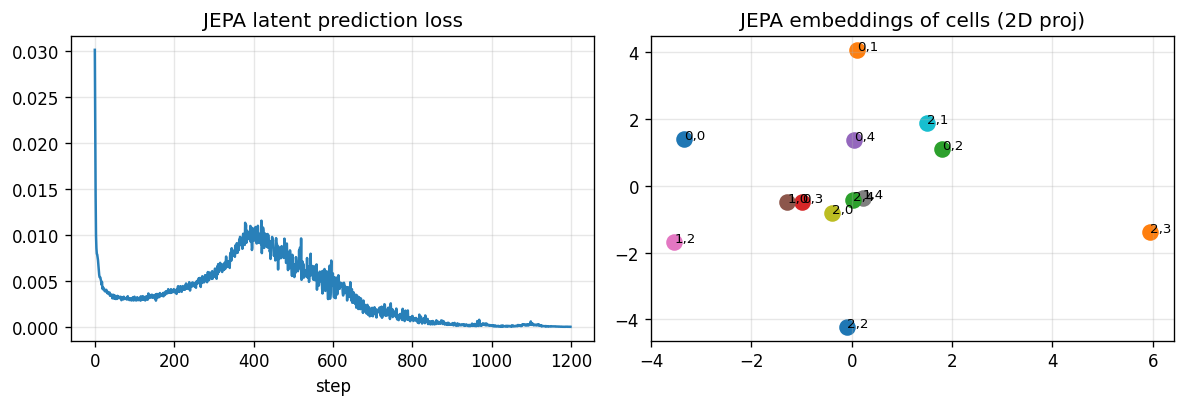

In [5]:
class JEPAWorld(nn.Module):
    def __init__(self, obs_dim, n_actions=4, z_dim=32, hidden=64):
        super().__init__()
        self.n_actions = n_actions
        self.context_enc = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(), nn.Linear(hidden, z_dim)
        )
        self.target_enc = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(), nn.Linear(hidden, z_dim)
        )
        # EMA copy of context_enc
        self.target_enc.load_state_dict(self.context_enc.state_dict())
        for p in self.target_enc.parameters():
            p.requires_grad = False
        self.predictor = nn.Sequential(
            nn.Linear(z_dim + n_actions, hidden), nn.Tanh(),
            nn.Linear(hidden, z_dim),
        )

    @torch.no_grad()
    def ema_update(self, tau=0.99):
        for p, pt in zip(self.context_enc.parameters(), self.target_enc.parameters()):
            pt.data.mul_(tau).add_(p.data, alpha=1 - tau)

    def forward(self, o, a, op):
        s = self.context_enc(o)
        a1 = F.one_hot(a, self.n_actions).float()
        s_hat = self.predictor(torch.cat([s, a1], dim=-1))
        with torch.no_grad():
            s_tgt = self.target_enc(op)
        return s_hat, s_tgt

jepa = JEPAWorld(obs_dim).to(device)
opt_j = torch.optim.Adam(
    list(jepa.context_enc.parameters()) + list(jepa.predictor.parameters()), lr=3e-3
)
j_losses = []
for step in range(1200):
    o, a, r, op = batchify(dataset)
    s_hat, s_tgt = jepa(o, a, op)
    loss = F.mse_loss(s_hat, s_tgt)
    opt_j.zero_grad(); loss.backward(); opt_j.step()
    jepa.ema_update(0.99)
    j_losses.append(loss.item())

print(f"JEPA final latent loss: {j_losses[-1]:.4f}")

# Probe: cosine sim of predicted vs target next latent on a batch
o, a, r, op = batchify(dataset, 256)
with torch.no_grad():
    s_hat, s_tgt = jepa(o, a, op)
    cos = F.cosine_similarity(s_hat, s_tgt, dim=-1).mean().item()
print(f"Mean cosine(pred, target next embed): {cos:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(j_losses, color="#2980B9")
axes[0].set_title("JEPA latent prediction loss")
axes[0].set_xlabel("step"); axes[0].grid(True, alpha=0.3)

# Compare: reconstruction world model vs JEPA — capacity spent
# Show that JEPA latent still clusters by true position
with torch.no_grad():
    positions = []
    embeds = []
    for r in range(H):
        for c in range(W):
            if LAYOUT[r][c] == "#":
                continue
            o = torch.tensor(obs_vector((r, c)), device=device).unsqueeze(0)
            z = jepa.context_enc(o).cpu().numpy()[0]
            positions.append((r, c))
            embeds.append(z)
embeds = np.stack(embeds)
# 2D PCA-ish via top 2 SVD dims
embeds_c = embeds - embeds.mean(0)
U, S, Vt = np.linalg.svd(embeds_c, full_matrices=False)
xy = embeds_c @ Vt[:2].T
for i, (r, c) in enumerate(positions):
    axes[1].scatter(xy[i, 0], xy[i, 1], s=80)
    axes[1].text(xy[i, 0], xy[i, 1], f"{r},{c}", fontsize=8)
axes[1].set_title("JEPA embeddings of cells (2D proj)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("WM_D_jepa.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Failure modes you must feel

| Failure | Symptom | Mitigation |
|---------|---------|------------|
| Compounding error | Long open-loop rollouts diverge | Short horizon MPC; latent consistency; ensembles |
| Model bias / hallucination | Imagined paths enter walls | Hard constraints; uncertainty penalties |
| Observational confounding | Bad $P(o'|a)$ under new policies | On-policy data; causal identification |
| Pixel overfit | Great recon, useless control | JEPA / reward-centric losses |
| Distributional shift | MPC exploits model errors | Pessimism, UBE-style uncertainty (research frontier) |

**Exercise thought:** If the model never saw action “Up” from a cell, imagination may invent illegal transitions — MCTS will happily exploit them.

Open-loop final-cell accuracy by horizon: [(1, 1.0), (2, 1.0), (3, 1.0), (5, 0.98), (8, 0.92)]


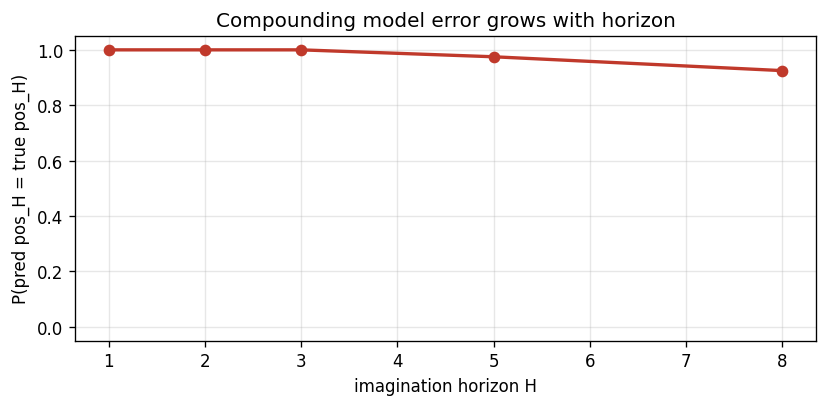

In [6]:
# Demonstrate compounding error: open-loop horizon vs position accuracy
def open_loop_accuracy(horizon, n_eps=40):
    hits = []
    for _ in range(n_eps):
        pos = START
        actions = [int(rng.integers(0, 4)) for _ in range(horizon)]
        pred, true, _, _ = imagine_trajectory(model, pos, actions)
        # compare final cell
        hits.append(float(pred[horizon] == true[horizon]))
    return float(np.mean(hits))

horizons = [1, 2, 3, 5, 8]
accs = [open_loop_accuracy(h) for h in horizons]
print("Open-loop final-cell accuracy by horizon:", list(zip(horizons, np.round(accs, 2))))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(horizons, accs, "o-", color="#C0392B", lw=2)
ax.set_xlabel("imagination horizon H")
ax.set_ylabel("P(pred pos_H = true pos_H)")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Compounding model error grows with horizon")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("WM_E_compounding_error.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Concept map & research bridges

```
World Models
│
├── Encode o_t → z_t
├── Dynamics z_{t+1} = f(z_t, a_t)     ← intervention semantics
├── Optional decode → ô, r̂
│
├── Train
│   ├── Reconstruction (Dreamer / PlaNet)
│   ├── Latent prediction (JEPA / BYOL-style)
│   └── Reward / value prediction (MuZero)
│
├── Act
│   ├── MPC (sample action sequences)
│   ├── MCTS in latent space (MuZero)
│   └── Actor-critic in imagination (Dreamer)
│
└── Hard problems
    ├── Compounding error
    ├── Uncertainty-aware planning (UBE, ensembles)
    └── Partial observability & stochasticity
```

### How this connects to earlier phases

| Earlier phase | World-model use |
|---------------|-----------------|
| Stability / eigenvalues | Latent dynamics must not explode |
| do-calculus | Actions in dyn are interventions |
| SSM / Mamba | Backbone for $f(z,a)$ over long video |
| MCTS | Search using learned $f$ instead of true env |
| Chaos / Lyapunov | Sensitivity of long imaginations |

### Summary table

| Concept | Role |
|---------|------|
| Encoder | Belief / state abstraction |
| Dynamics | Learned $P(z'|z,\mathrm{do}(a))$ |
| Decoder | Optional human-interpretable readout |
| Latent consistency / JEPA | Predict abstractions, not textures |
| MPC / MCTS | Turn model into a policy via search |
| Horizon tradeoff | Longer search needs better model |

---

## 9. References

- Ha & Schmidhuber (2018) — World Models  
- Hafner et al. — PlaNet, Dreamer, DreamerV2/V3  
- Schrittwieser et al. (2020) — MuZero  
- LeCun — A Path Towards Autonomous Machine Intelligence (JEPA)  
- Bardes et al. — V-JEPA  
- Micheli et al. — Transformers are Sample-Efficient World Models  

---

## 10. Exercises

1. Remove the latent consistency term and re-train — does open-loop accuracy drop?  
2. Train only on random policy data; run MPC — does it avoid the trap?  
3. Add a second “ensemble” model with different seed; plan with **worst-case** imagined return (pessimism).  
4. Replace one-hot obs with noisy obs (flip bits) — does JEPA embedding stay clustered by cell?  
5. (Bridge to Phase 8) Fine-tune the world model for 20 steps on a *modified* grid (trap moved) — how fast does MPC recover?